# Lecture 4 — Class Exercise
## Scatter & Bubble Charts: Gapminder

> **Push to:** `week04/lecture04_exercise.ipynb`

**Rules:**
1. Colour used **sparingly** — one categorical variable, no rainbow
2. If showing all continents, either use accessible palette OR grey all + highlight one
3. `size_max` set when using bubble size
4. Log scale for GDP per capita
5. Insight title

---


In [2]:
import pandas as pd
import plotly.express as px

# Dataset: Gapminder — GDP, Life Expectancy, Population by Country
# Source: Gapminder Foundation (gapminder.org)

df = px.data.gapminder()
print(f"Loaded: {len(df)} rows")
print(df.head())

Loaded: 1704 rows
       country continent  year  lifeExp       pop   gdpPercap iso_alpha  \
0  Afghanistan      Asia  1952   28.801   8425333  779.445314       AFG   
1  Afghanistan      Asia  1957   30.332   9240934  820.853030       AFG   
2  Afghanistan      Asia  1962   31.997  10267083  853.100710       AFG   
3  Afghanistan      Asia  1967   34.020  11537966  836.197138       AFG   
4  Afghanistan      Asia  1972   36.088  13079460  739.981106       AFG   

   iso_num  
0        4  
1        4  
2        4  
3        4  
4        4  


In [3]:
# explore

print(df.info())
print("Years:", sorted(df['year'].unique()))
print("Continents:", df['continent'].unique())
print(df.describe().round(1))


<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1704 entries, 0 to 1703
Data columns (total 8 columns):
 #   Column     Non-Null Count  Dtype  
---  ------     --------------  -----  
 0   country    1704 non-null   object 
 1   continent  1704 non-null   object 
 2   year       1704 non-null   int64  
 3   lifeExp    1704 non-null   float64
 4   pop        1704 non-null   int64  
 5   gdpPercap  1704 non-null   float64
 6   iso_alpha  1704 non-null   object 
 7   iso_num    1704 non-null   int64  
dtypes: float64(2), int64(3), object(3)
memory usage: 106.6+ KB
None
Years: [np.int64(1952), np.int64(1957), np.int64(1962), np.int64(1967), np.int64(1972), np.int64(1977), np.int64(1982), np.int64(1987), np.int64(1992), np.int64(1997), np.int64(2002), np.int64(2007)]
Continents: ['Asia' 'Europe' 'Africa' 'Americas' 'Oceania']
         year  lifeExp           pop  gdpPercap  iso_num
count  1704.0   1704.0  1.704000e+03     1704.0   1704.0
mean   1979.5     59.5  2.960121e+07     7215.3    

## Task 1 — Scatter: life expectancy change over time

**What to build:** A scatter showing **GDP per capita vs life expectancy** for **two years** (2000 and 2007) to show how both moved — use **colour for year** (just 2 colours), **one continent only**.

Choose any continent except Africa (that was the example). Highlight the change direction.

> 💡 Filter: `df.loc[df['continent'] == 'YOUR_CHOICE']` then filter years


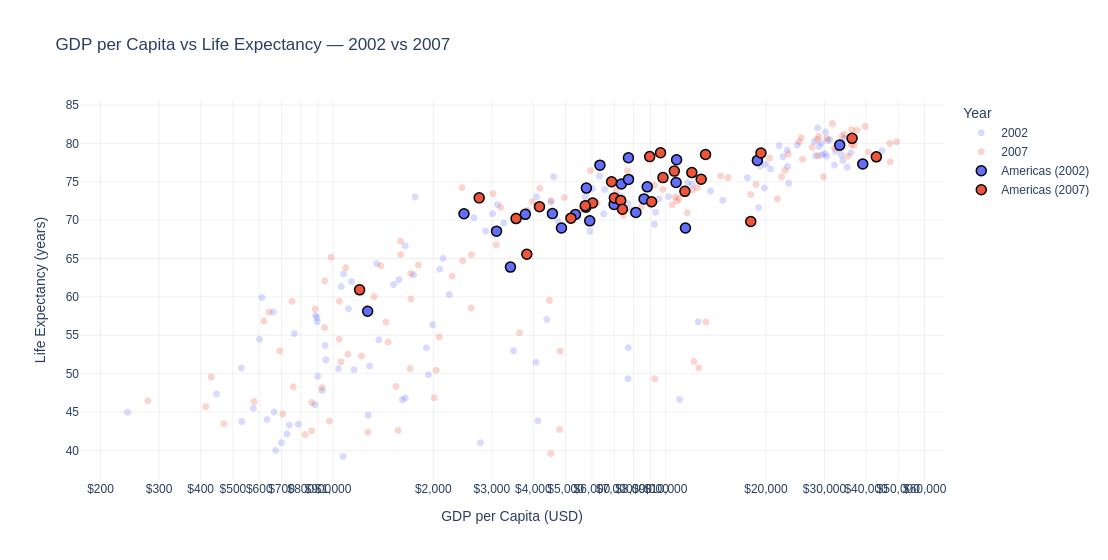

In [4]:
df_filtered = df[df['year'].isin([2002, 2007])].copy()
df_filtered['year'] = df_filtered['year'].astype(str)

df_americas = df_filtered.loc[df_filtered['continent'] == 'Americas']
df_rest = df_filtered[df_filtered['continent'] != 'Americas']

fig = px.scatter(
    df_rest,
    x='gdpPercap',
    y='lifeExp',
    color='year',
    color_discrete_map={'2002': '#636EFA', '2007': '#EF553B'},
    log_x=True,
    labels={
        'gdpPercap': 'GDP per Capita (USD)',
        'lifeExp': 'Life Expectancy (years)',
        'year': 'Year'
    },
    title='GDP per Capita vs Life Expectancy — 2002 vs 2007'
)

for trace in fig.data:
    trace.marker.opacity = 0.25
    trace.marker.size = 7
    trace.hovertemplate = (
        '<b>%{customdata[0]}</b><br>'
        'GDP per Capita: $%{x:,.0f}<br>'
        'Life Expectancy: %{y:.1f} yrs<extra></extra>'
    )
    trace.customdata = df_rest[df_rest['year'] == trace.name][['country']].values

for year, color in [('2002', '#636EFA'), ('2007', '#EF553B')]:
    group = df_americas[df_americas['year'] == year]
    fig.add_scatter(
        x=group['gdpPercap'],
        y=group['lifeExp'],
        mode='markers',
        name=f'Americas ({year})',
        marker=dict(
            color=color,
            size=10,
            opacity=1.0,
            line=dict(color='black', width=1.5)
        ),
        hovertemplate=(
            '<b>%{customdata[0]}</b><br>'
            'GDP per Capita: $%{x:,.0f}<br>'
            'Life Expectancy: %{y:.1f} yrs<extra></extra>'
        ),
        customdata=group[['country']].values
    )

fig.update_layout(
    xaxis=dict(tickformat='$,.0f', gridcolor='rgba(0,0,0,0.06)'),
    yaxis=dict(gridcolor='rgba(0,0,0,0.06)'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hoverlabel=dict(font_color='white'),
    width=850,
    height=560
)

fig.show()

## Task 2 — Bubble chart: tell a story

**What to build:** A bubble chart (full 2007 dataset, all countries) where:
- x = GDP per capita (log scale)
- y = life expectancy
- size = population
- colour = ONE continent highlighted (your choice), all others grey
- At least one annotation explaining the highlighted group's story

> This is the grey-and-highlight technique applied to a bubble chart.


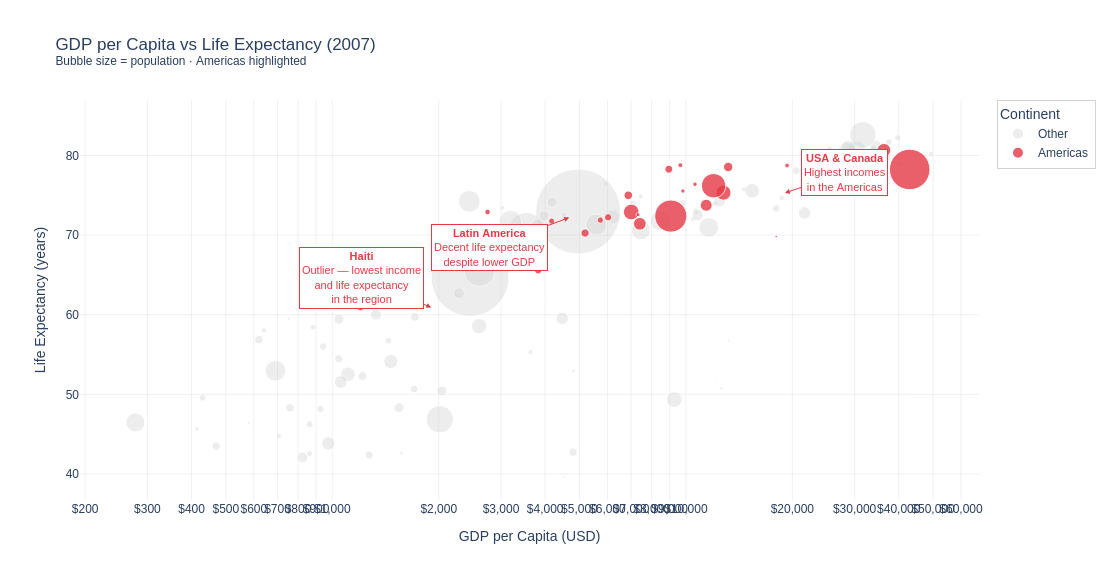

In [7]:
df_2007 = df[df['year'] == 2007].copy()

highlight_continent = 'Americas'
df_2007['color_group'] = df_2007['continent'].apply(
    lambda x: x if x == highlight_continent else 'Other'
)

fig = px.scatter(
    df_2007,
    x='gdpPercap',
    y='lifeExp',
    size='pop',
    color='color_group',
    color_discrete_map={highlight_continent: '#E63946', 'Other': 'lightgrey'},
    size_max=60,
    log_x=True,
    hover_name='country',
    hover_data={'gdpPercap': ':,.0f', 'lifeExp': ':.1f', 'pop': False, 'color_group': False},
    labels={
        'gdpPercap': 'GDP per Capita (USD)',
        'lifeExp': 'Life Expectancy (years)',
        'color_group': 'Continent'
    },
    title='GDP per Capita vs Life Expectancy (2007)<br>'
          '<sup>Bubble size = population · Americas highlighted</sup>',
)

# Mute opacity on grey trace only
for trace in fig.data:
    if trace.name == 'Other':
        trace.marker.opacity = 0.4
    else:
        trace.marker.opacity = 0.8

fig.update_layout(
    xaxis=dict(tickformat='$,.0f', gridcolor='rgba(0,0,0,0.06)'),
    yaxis=dict(gridcolor='rgba(0,0,0,0.06)'),
    plot_bgcolor='white',
    paper_bgcolor='white',
    hoverlabel=dict(font_color='white'),
    legend=dict(bordercolor='lightgrey', borderwidth=1),
    width=900,
    height=580,
    annotations=[
        dict(
            x=4.28, y=75.3,
            xref='x', yref='y',
            text='<b>USA & Canada</b><br>Highest incomes<br>in the Americas',
            showarrow=True,
            arrowhead=2,
            arrowcolor='#E63946',
            ax=60, ay=-20,
            font=dict(size=11, color='#E63946'),
            bgcolor='white',
            bordercolor='#E63946',
            borderwidth=1
        ),
        dict(
            x=3.67, y=72.2,
            xref='x', yref='y',
            text='<b>Latin America</b><br>Decent life expectancy<br>despite lower GDP',
            showarrow=True,
            arrowhead=2,
            arrowcolor='#E63946',
            ax=-80, ay=30,
            font=dict(size=11, color='#E63946'),
            bgcolor='white',
            bordercolor='#E63946',
            borderwidth=1
        ),
        dict(
            x=3.28, y=60.9,
            xref='x', yref='y',
            text='<b>Haiti</b><br>Outlier — lowest income<br>and life expectancy<br>in the region',
            showarrow=True,
            arrowhead=2,
            arrowcolor='#E63946',
            ax=-70, ay=-30,
            font=dict(size=11, color='#E63946'),
            bgcolor='white',
            bordercolor='#E63946',
            borderwidth=1
        )
    ]
)

fig.show()
